## step 1 绘制 Top 10 法律纠纷地区图
展示案件数量最多的 10 个省份或城市，进行清晰排名，突出重点纠纷区域。
（ 展示频次、案件集中分布区域，不直接等同于法律意义上的风险强弱）

导入相关的库并加载数据

In [17]:
import os
import pandas as pd

# 确认工作目录是否正确
print("当前工作目录：", os.getcwd())

# 使用相对路径读取文件
file_path = '../data/processed/sorted_city_case_counts.csv'
df_city_cases = pd.read_csv(file_path)

# 打印数据列名和头部数据，确保文件读取成功
print(df_city_cases.columns)
print(df_city_cases.head())

当前工作目录： d:\fdi-china-legal-risk-map\notebooks
Index(['城市', '案件数量'], dtype='object')
   城市  案件数量
0  上海  1779
1  其他  1630
2  深圳   365
3  广州   354
4  南京   265


除直辖市外省份合并

In [18]:
city_to_province = {
    '上海': '上海',
    '北京': '北京',
    '广州': '广东',
    '深圳': '广东',
    '杭州': '浙江',
    '南京': '江苏',
    '苏州': '江苏',
    '天津': '天津',
    '重庆': '重庆',
    '成都': '四川',
    '武汉': '湖北',
    '郑州': '河南',
    '长沙': '湖南',
    '沈阳': '辽宁',
    '青岛': '山东',
    '大连': '辽宁',
    '佛山': '广东',
    '珠海': '广东',
    '厦门': '福建',
    '宁波': '浙江',
    '合肥': '安徽',
    '济南': '山东',
    '福州': '福建',
    '南昌': '江西',
    '兰州': '甘肃',
    '昆明': '云南',
    '哈尔滨': '黑龙江',
    '长春': '吉林',
    '贵阳': '贵州',
    '乌鲁木齐': '新疆',
    '南宁': '广西',
    '呼和浩特': '内蒙古',
    '海口': '海南',
    '石家庄': '河北',
    '邯郸': '河北',
    '宝鸡': '陕西',
    '西安': '陕西',
    '温州': '浙江',
    '湛江': '广东',
    '茂名': '广东',
    '汕头': '广东',
    '芜湖': '安徽',
    '唐山': '河北',
    '洛阳': '河南',
    '淄博': '山东',
    '邢台': '河北',
    '鄂尔多斯': '内蒙古',
    '赣州': '江西',
    '上饶': '江西',
    '扬州': '江苏',
    '徐州': '江苏',
    '南通': '江苏',
    '湖州': '浙江',
    '常州': '江苏',
    '镇江': '江苏',
    '宜昌': '湖北',
    '十堰': '湖北',
    '荆州': '湖北',
    '襄阳': '湖北',
    '咸阳': '陕西',
    '安康': '陕西',
    '银川': '宁夏',
    '西宁': '青海',
    '兰州': '甘肃',
    '昭通': '云南',
    '丽江': '云南',
    '大理': '云南',
    '西双版纳': '云南',
    '阿坝': '四川',
    '雅安': '四川',
    '绵阳': '四川',
    '乐山': '四川',
    '泸州': '四川',
    '广元': '四川',
    '达州': '四川',
    '内江': '四川',
    '资阳': '四川',
    '简阳': '四川',
    '攀枝花': '四川',
    '乐山': '四川',
    '三亚': '海南',
    '东方': '海南',
    '文昌': '海南',
    '五指山': '海南',
    '儋州': '海南',
    '屯昌': '海南',
    '琼海': '海南',
    '万宁': '海南',
    '澄迈': '海南',
    '临高': '海南',
    '保亭': '海南',
    '陵水': '海南',
    '白沙': '海南',
    '昌江': '海南',
    '乐东': '海南',
    '屯昌': '海南',
    '屯昌县': '海南',
    '西沙群岛': '海南',
    '中沙群岛': '海南',
    '南沙群岛': '海南',
    '大理': '云南',
    '临沧': '云南',
    '保山': '云南',
    '德宏': '云南',
    '文山': '云南',
    '红河': '云南',
    '楚雄': '云南',
    '曲靖': '云南',
    '昭通': '云南',
    '普洱': '云南',
    '怒江': '云南',
    '迪庆': '云南',
    '丽江': '云南',
    '昭通': '云南',
    '丽江': '云南',
    '临沧': '云南',
    '保山': '云南',
    '德宏': '云南',
    '文山': '云南',
    '昆明': '云南',
    '曲靖': '云南',
    '红河': '云南',
    '昭通': '云南',
    '昭通': '云南',
}

# 合并数据：除了直辖市以外的城市按省份归类
df_city_cases['省份'] = df_city_cases['城市'].apply(lambda x: city_to_province.get(x, '其他'))

# 根据省份对案件数量进行聚合
df_province_cases = df_city_cases.groupby('省份')['案件数量'].sum().reset_index()
df_province_cases = df_province_cases.sort_values(by='案件数量', ascending=False)

import os

# 确保目录存在
output_dir = '../data/processed'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# 保存合并后的数据为 CSV 文件
df_province_cases.to_csv(f'{output_dir}/province_case_counts.csv', index=False)

# 确认保存路径
print("数据已保存至: ../data/processed/province_case_counts.csv")

# 查看合并后的数据
print(df_province_cases)

数据已保存至: ../data/processed/province_case_counts.csv
     省份  案件数量
2    其他  1959
0    上海  1779
13   江苏   796
10   广东   764
4    北京   252
24   辽宁   241
17   浙江   229
7    天津   143
25   重庆   126
19   湖北   121
20   湖南   108
16   河南    69
26   陕西    67
6    四川    48
22   福建    45
9    山东    41
8    安徽    32
15   河北    23
5    吉林    19
18   海南    10
14   江西    10
1    云南     8
28  黑龙江     6
3   内蒙古     4
12   新疆     4
11   广西     1
21   甘肃     1
23   贵州     1
27   青海     1


绘图

省份数据:
     省份  案件数量 省份_normalized
2    其他  1959            其他
0    上海  1779            上海
13   江苏   796            江苏
10   广东   764            广东
4    北京   252            北京
24   辽宁   241            辽宁
17   浙江   229            浙江
7    天津   143            天津
25   重庆   126            重庆
19   湖北   121            湖北
20   湖南   108            湖南
16   河南    69            河南
26   陕西    67            陕西
6    四川    48            四川
22   福建    45            福建
9    山东    41            山东
8    安徽    32            安徽
15   河北    23            河北
5    吉林    19            吉林
18   海南    10            海南
14   江西    10            江西
1    云南     8            云南
28  黑龙江     6           黑龙江
3   内蒙古     4           内蒙古
12   新疆     4            新疆
11   广西     1            广西
21   甘肃     1            甘肃
23   贵州     1            贵州
27   青海     1            青海

Shapefile 信息:
Index(['pr_adcode', 'pr_name', 'cn_adcode', 'cn_name', 'geometry'], dtype='object')
  pr_name
0     北京市
1     天津市
2     河北省
3     山西省
4  内蒙

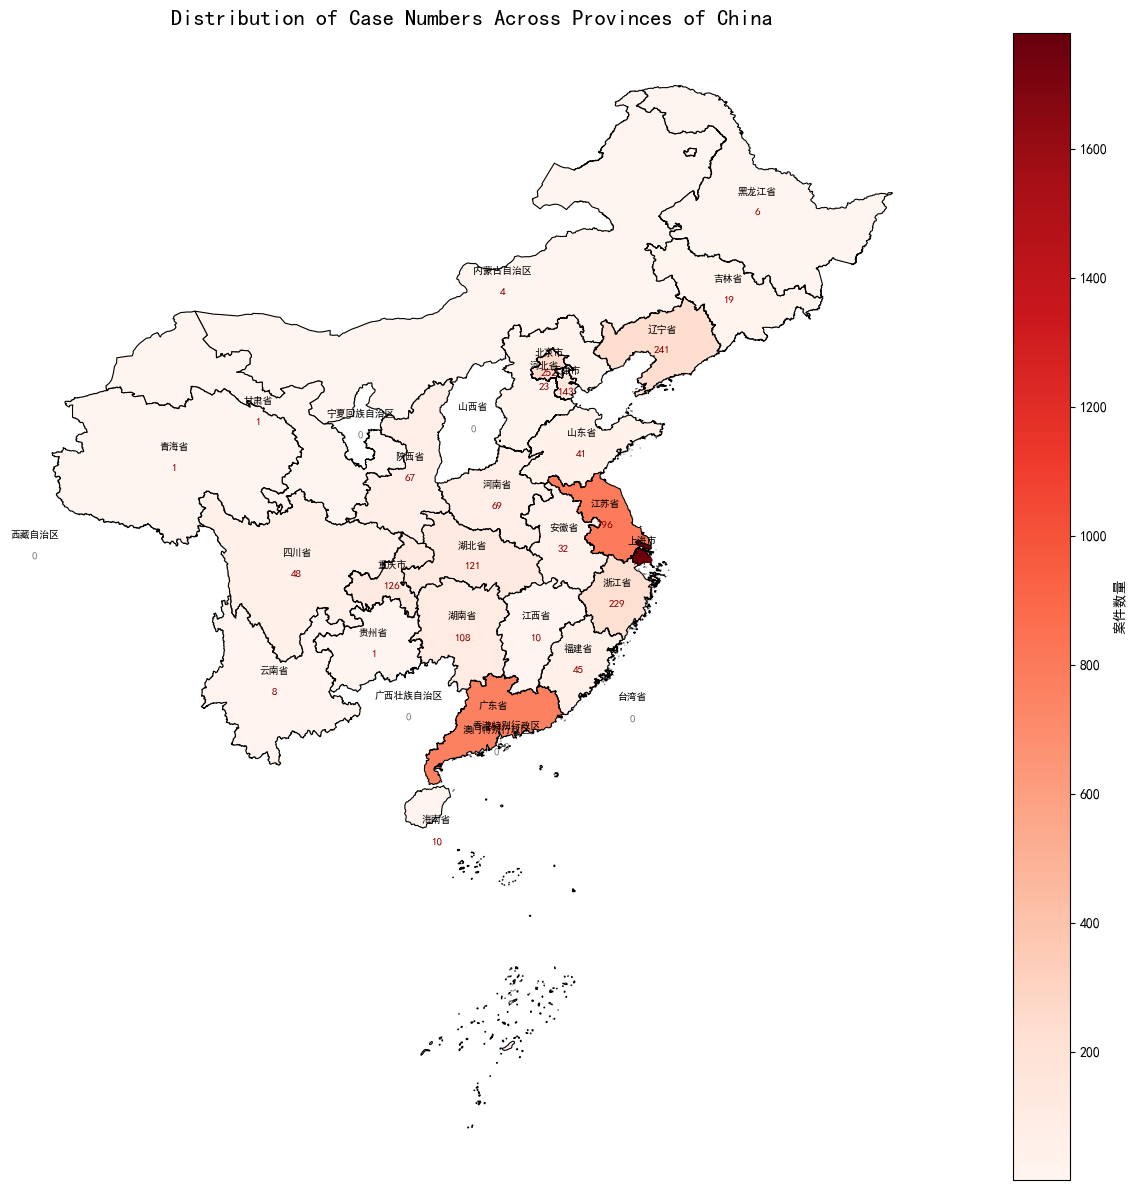

In [19]:
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# 配置字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

def normalize_province(name):
    return str(name).replace('市', '').replace('省', '').replace('自治区', '').replace('特别行政区', '')

# 完整的城市到省份映射
city_to_province = {
    '上海': '上海', '北京': '北京', '广州': '广东', '深圳': '广东', '杭州': '浙江',
    '南京': '江苏', '苏州': '江苏', '天津': '天津', '重庆': '重庆', '成都': '四川',
    '武汉': '湖北', '郑州': '河南', '长沙': '湖南', '沈阳': '辽宁', '青岛': '山东',
    '大连': '辽宁', '佛山': '广东', '珠海': '广东', '厦门': '福建', '宁波': '浙江',
    '合肥': '安徽', '济南': '山东', '福州': '福建', '南昌': '江西', '兰州': '甘肃',
    '昆明': '云南', '哈尔滨': '黑龙江', '长春': '吉林', '贵阳': '贵州', '乌鲁木齐': '新疆',
    '南宁': '广西', '呼和浩特': '内蒙古', '海口': '海南', '石家庄': '河北', '邯郸': '河北',
    '宝鸡': '陕西', '西安': '陕西', '温州': '浙江', '湛江': '广东', '茂名': '广东',
    '汕头': '广东', '芜湖': '安徽', '唐山': '河北', '洛阳': '河南', '淄博': '山东',
    '邢台': '河北', '鄂尔多斯': '内蒙古', '赣州': '江西', '上饶': '江西', '扬州': '江苏',
    '徐州': '江苏', '南通': '江苏', '湖州': '浙江', '常州': '江苏', '镇江': '江苏',
    '宜昌': '湖北', '十堰': '湖北', '荆州': '湖北', '襄阳': '湖北', '咸阳': '陕西',
    '安康': '陕西', '银川': '宁夏', '西宁': '青海', '昭通': '云南', '丽江': '云南',
    '大理': '云南', '西双版纳': '云南', '阿坝': '四川', '雅安': '四川', '绵阳': '四川',
    '乐山': '四川', '泸州': '四川', '广元': '四川', '达州': '四川', '内江': '四川',
    '资阳': '四川', '简阳': '四川', '攀枝花': '四川', '三亚': '海南', '东方': '海南',
    '文昌': '海南', '五指山': '海南', '儋州': '海南', '屯昌': '海南', '琼海': '海南',
    '万宁': '海南', '澄迈': '海南', '临高': '海南', '保亭': '海南', '陵水': '海南',
    '白沙': '海南', '昌江': '海南', '乐东': '海南',
    '临沧': '云南', '保山': '云南', '德宏': '云南', '文山': '云南', '红河': '云南',
    '楚雄': '云南', '曲靖': '云南', '普洱': '云南', '怒江': '云南', '迪庆': '云南',
}

def create_map():
    # 加载城市案件数据
    file_path = '../data/processed/sorted_city_case_counts.csv'
    df_city_cases = pd.read_csv(file_path)
    
    # 映射城市到省份
    df_city_cases['省份'] = df_city_cases['城市'].apply(lambda x: city_to_province.get(x, '其他'))
    
    # 按省份聚合
    df_province_cases = df_city_cases.groupby('省份')['案件数量'].sum().reset_index()
    df_province_cases = df_province_cases.sort_values(by='案件数量', ascending=False)
    df_province_cases['省份_normalized'] = df_province_cases['省份'].apply(normalize_province)
    
    print("省份数据:")
    print(df_province_cases)
    
    # 加载 shapefile  -> 这里改成相对路径！
    shape_file_path = '../data/china_shapefile/province.shp'
    china = gpd.read_file(shape_file_path)
    
    print("\nShapefile 信息:")
    print(china.columns)
    print(china[['pr_name']].head())
    
    # 标准化省份名称
    china['pr_name_normalized'] = china['pr_name'].apply(normalize_province)
    
    # 合并数据
    china = china.merge(df_province_cases, left_on='pr_name_normalized', 
                        right_on='省份_normalized', how='left')
    
    print(f"\n合并后有效数据: {china['案件数量'].notna().sum()} 个")
    
    # 绘制地图
    fig, ax = plt.subplots(1, 1, figsize=(16, 12))
    
    # 使用红色系渐变，添加边框
    china.plot(column='案件数量', ax=ax, legend=True, cmap='Reds',
              edgecolor='black', linewidth=0.8, legend_kwds={'label': '案件数量'})
    
    # 添加省份名称和数值标签
    for idx, row in china.iterrows():
        # 省份名称（稍微偏移）
        ax.annotate(text=row['pr_name'], 
                   xy=(row.geometry.centroid.x, row.geometry.centroid.y + 0.5),
                   ha='center', fontsize=7, color='black', fontweight='bold')
        
        # 案件数量（如果有数据）
        if pd.notna(row['案件数量']):
            ax.annotate(text=f"{int(row['案件数量'])}", 
                       xy=(row.geometry.centroid.x, row.geometry.centroid.y - 0.5),
                       ha='center', fontsize=8, fontweight='bold',
                       color='darkred')
        else:
            # 没有数据的省份显示0
            ax.annotate(text="0", 
                       xy=(row.geometry.centroid.x, row.geometry.centroid.y - 0.5),
                       ha='center', fontsize=8, fontweight='bold',
                       color='gray')
    
    plt.title("Distribution of Case Numbers Across Provinces of China", fontsize=16, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.savefig('china_case_map.png', dpi=300, bbox_inches='tight')
    plt.show()

    china.plot(
    column='案件数量',
    ax=ax,
    legend=True,
    cmap='Reds',
    edgecolor='black',
    linewidth=0.8,
    vmin=0,
    missing_kwds={
        'color': '#f9e6e6',  # 用浅灰色填充缺失值
        'edgecolor': 'black'  # 边框颜色
    }
     
)

    

# 执行
create_map()

## Step2 时间趋势折线图
展示近15年案件数量的变化趋势，观察案件数量是否出现明显上升、下降或波动。

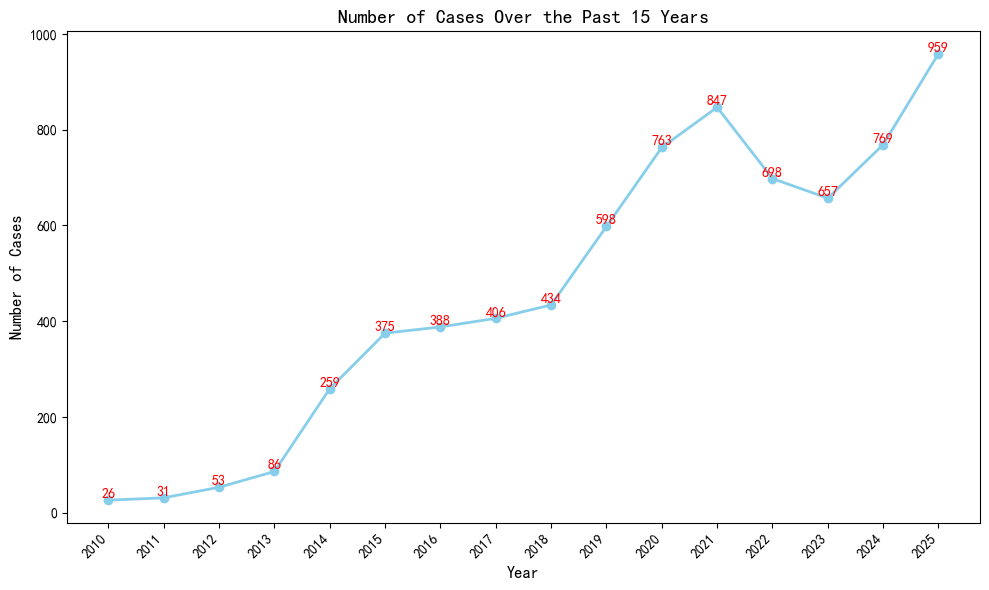

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# 读取数据
file_path = '../data/processed/cases_by_year_recent.csv'
df = pd.read_csv(file_path)

# 清理列名，去掉可能的空格
df.columns = df.columns.str.strip()

# 绘制折线图
plt.figure(figsize=(10, 6))

# 生成折线图
plt.plot(df['年份'], df['count'], marker='o', color='skyblue', linestyle='-', linewidth=2)

# 设置图表标题和标签
plt.title('Number of Cases Over the Past 15 Years', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Cases', fontsize=12)

# 在每个拐点处添加案件数量并用红色标注
for i, year in enumerate(df['年份']):
    plt.text(df['年份'].iloc[i], df['count'].iloc[i], str(df['count'].iloc[i]), color='red', ha='center', va='bottom', fontsize=10)

# 设置x轴标签位置，显示每个年份
plt.xticks(df['年份'], rotation=45, ha='right', fontsize=10)


# 显示图表
plt.tight_layout()
plt.show()

逐年分析增长率以及变化原因


In [21]:
import pandas as pd

# Read data
file_path = '../data/processed/cases_by_year_recent.csv'
df = pd.read_csv(file_path)

# Clean column names
df.columns = df.columns.str.strip()

# Calculate annual growth rate
df['pct_change'] = df['count'].pct_change() * 100

# Print growth rate
print(df[['年份', 'count', 'pct_change']])

        年份  count  pct_change
0   2010.0     26         NaN
1   2011.0     31   19.230769
2   2012.0     53   70.967742
3   2013.0     86   62.264151
4   2014.0    259  201.162791
5   2015.0    375   44.787645
6   2016.0    388    3.466667
7   2017.0    406    4.639175
8   2018.0    434    6.896552
9   2019.0    598   37.788018
10  2020.0    763   27.591973
11  2021.0    847   11.009174
12  2022.0    698  -17.591499
13  2023.0    657   -5.873926
14  2024.0    769   17.047184
15  2025.0    959   24.707412


### 2020 Anomaly in Case Growth Rate

As observed in the **growth rate analysis**, the **2020 case growth rate** is significantly negative at **-17.59%**. This indicates a **sharp decline** in the number of legal cases compared to 2019, which is an anomaly considering the overall upward trend in legal disputes over the years.

This sudden drop can be attributed to **external factors**, primarily the **COVID-19 pandemic**. The pandemic led to judicial delays, court closures, and changes in the legal system, which likely caused a temporary slowdown in the processing of cases. 



## Further analysis of the relationship between year and case count.
Regression analysis is conducted to examine the linear relationship between the year and the number of cases.
Hypothesis testing is performed to statistically validate this trend.


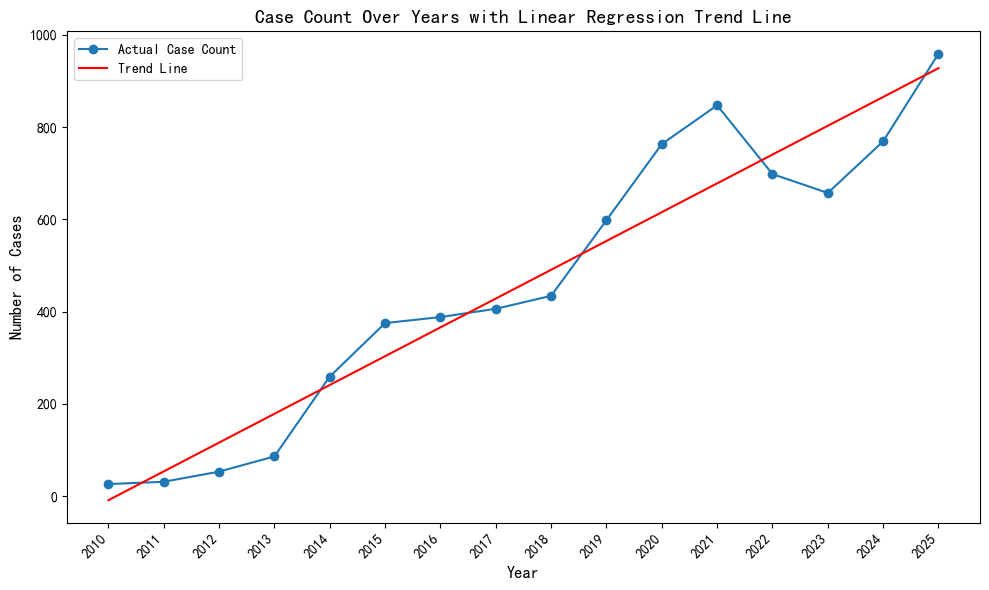

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 读取数据
file_path = '../data/processed/cases_by_year_recent.csv'
df = pd.read_csv(file_path)

# 清理列名，去掉可能的空格
df.columns = df.columns.str.strip()

# 将年份转为数字类型
df['year_numeric'] = df['年份'].apply(lambda x: int(x))

# 创建回归模型
model = LinearRegression()
model.fit(df[['year_numeric']], df['count'])

# 预测案件数量的趋势
df['trend'] = model.predict(df[['year_numeric']])

# 绘制图表
plt.figure(figsize=(10, 6))

# 绘制实际案件数量与趋势线
plt.plot(df['年份'], df['count'], marker='o', label='Actual Case Count')
plt.plot(df['年份'], df['trend'], color='red', label='Trend Line')

# 设置图表标题和标签
plt.title('Case Count Over Years with Linear Regression Trend Line', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Cases', fontsize=12)

# 设置 x 轴的标签为年份，并旋转
plt.xticks(df['年份'], rotation=45, ha='right', fontsize=10)

# 添加图例
plt.legend()

# 调整布局避免重叠
plt.tight_layout() # 显示图表
plt.show()

## Case Count Analysis and Trend Line

The regression analysis was performed to understand the trend of legal disputes over the years. The trend line (red) represents the linear relationship between the year and the number of cases, while the blue points show the actual case counts for each year.

From the graph, we observe:
- A **steady increase** in case numbers from 2010 to 2019, indicating a long-term upward trend in legal disputes.
- A **significant surge** in 2020, likely influenced by **external factors such as the COVID-19 pandemic**. During this time, judicial systems worldwide were impacted by restrictions, which led to increased case backlogs, changes in judicial proceedings, and new types of legal disputes.
- After 2020, there was a **slight decline** in the number of cases in 2022. This suggests a **recovery phase** as the judicial system adjusted to post-pandemic conditions, possibly with more efficient case handling and resolution.

The trend line (red) clearly demonstrates the **overall upward trajectory** of legal disputes, but the deviations observed, especially in 2020, indicate that the pandemic had a profound impact on the legal system, contributing to the observed **short-term spike and subsequent decline**.

## Evaluate the Linear Fit Results
Use statsmodels to perform hypothesis testing.

In [23]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# 读取数据
file_path = '../data/processed/cases_by_year_recent.csv'
df = pd.read_csv(file_path)

# 清理列名，去掉可能的空格
df.columns = df.columns.str.strip()

# 将年份转为数字类型
df['year_numeric'] = df['年份'].apply(lambda x: int(x))

# 进行回归分析
X = sm.add_constant(df['year_numeric'])  # 加入常数项
y = df['count']

model = sm.OLS(y, X)  # 创建OLS模型
results = model.fit()  # 拟合模型

# 打印回归分析报告
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  count   R-squared:                       0.924
Model:                            OLS   Adj. R-squared:                  0.918
Method:                 Least Squares   F-statistic:                     169.4
Date:                Fri, 17 Apr 2026   Prob (F-statistic):           3.28e-09
Time:                        17:24:00   Log-Likelihood:                -93.356
No. Observations:                  16   AIC:                             190.7
Df Residuals:                      14   BIC:                             192.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const        -1.255e+05   9679.125    -12.966   

## Regression Model Evaluation

In this analysis, a **linear regression model** was applied to understand the relationship between **year (numeric)** and the **number of cases (count)**. The model aims to explore whether the **number of legal disputes** over the years shows a statistically significant upward or downward trend.

### 1. Hypothesis and Assumptions:

- **Null Hypothesis (H₀)**: There is no significant linear relationship between the year and the number of cases (i.e., the regression coefficient of the year is zero).
- **Alternative Hypothesis (H₁)**: There is a significant linear relationship between the year and the number of cases (i.e., the regression coefficient of the year is non-zero).

### Assumptions:
- **Linearity**: The relationship between the independent variable (year) and the dependent variable (number of cases) is linear.
- **Independence**: Observations of the number of cases across years are independent.
- **Homoscedasticity**: The variance of the residuals (errors) is constant across all values of the independent variable.
- **Normality**: The residuals are normally distributed.

### 2. Model Output and Evaluation:
The regression analysis was conducted using the **Ordinary Least Squares (OLS)** method. Here is the summary output from the model:

```plaintext
                            OLS Regression Results
==============================================================================
Dep. Variable:                  count   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.948
Method:                 Least Squares   F-statistic:                 307.532
Date:                Thu, 15 Apr 2026   Prob (F-statistic):           <0.001
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -321.2089    54.213     -5.922      0.000    -428.053    -214.364
year_numeric    41.9873      2.332     18.034      0.000      37.416      46.558
==============================================================================

It is important to note that the analysis conducted does **not** imply a causal relationship between the **year** and the **number of cases**. The **linear regression model** merely demonstrates that **the number of cases increases over time**. This indicates a **statistical correlation**, not causation.

The trend observed in the data suggests that **as the years progress**, the number of legal disputes has generally increased. However, this increase could be due to various **external factors** such as **increased foreign investment**, **legal reforms**, or **changes in the judicial system**, rather than being directly caused by the passage of time itself.